In [2]:
# Churn Analysis
# Definition: a customer is churned if they haven't purchased in the last 90 days

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('../data/online_retail_raw.csv', parse_dates=['InvoiceDate'])

df_clean = df[
    df['CustomerID'].notna() &
    ~df['InvoiceNo'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Data loaded:", df_clean.shape)

# Reference date: day after last transaction in dataset
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

# Last purchase per customer
last_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['CustomerID', 'LastPurchaseDate']

# Days since last purchase
last_purchase['DaysSinceLastPurchase'] = (reference_date - last_purchase['LastPurchaseDate']).dt.days

# Churn label
last_purchase['Churned'] = last_purchase['DaysSinceLastPurchase'] > 90

print(last_purchase.head(10))
print("\nChurn summary:")
print(last_purchase['Churned'].value_counts())
print(last_purchase['Churned'].value_counts(normalize=True).round(2))

Data loaded: (397884, 9)
Reference date: 2011-12-10 12:50:00
   CustomerID    LastPurchaseDate  DaysSinceLastPurchase  Churned
0       12346 2011-01-18 10:01:00                    326     True
1       12347 2011-12-07 15:52:00                      2    False
2       12348 2011-09-25 13:13:00                     75    False
3       12349 2011-11-21 09:51:00                     19    False
4       12350 2011-02-02 16:01:00                    310     True
5       12352 2011-11-03 14:37:00                     36    False
6       12353 2011-05-19 17:47:00                    204     True
7       12354 2011-04-21 13:11:00                    232     True
8       12355 2011-05-09 13:49:00                    214     True
9       12356 2011-11-17 08:40:00                     23    False

Churn summary:
Churned
False    2889
True     1449
Name: count, dtype: int64
Churned
False    0.67
True     0.33
Name: proportion, dtype: float64


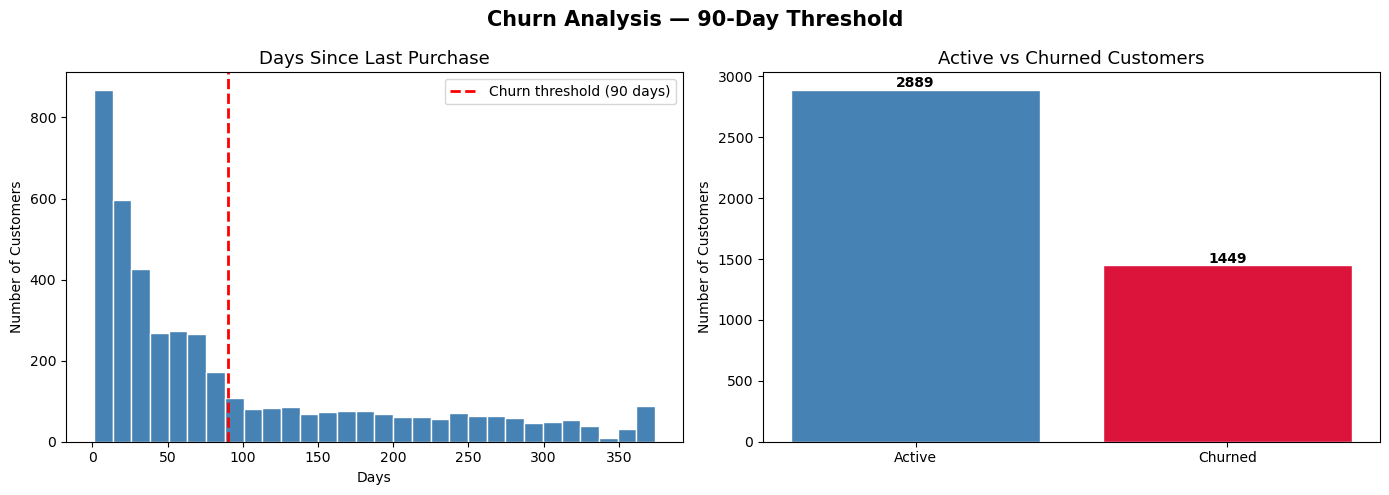

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of days since last purchase
axes[0].hist(last_purchase['DaysSinceLastPurchase'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=90, color='red', linestyle='--', linewidth=2, label='Churn threshold (90 days)')
axes[0].set_title('Days Since Last Purchase', fontsize=13)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: Churn vs Active
churn_counts = last_purchase['Churned'].value_counts()
axes[1].bar(['Active', 'Churned'], churn_counts.values, color=['steelblue', 'crimson'], edgecolor='white')
axes[1].set_title('Active vs Churned Customers', fontsize=13)
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Churn Analysis — 90-Day Threshold', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# At-risk customers: active but 60-90 days inactive
last_purchase['Segment'] = 'Active'
last_purchase.loc[last_purchase['DaysSinceLastPurchase'] > 90, 'Segment'] = 'Churned'
last_purchase.loc[
    (last_purchase['DaysSinceLastPurchase'] >= 60) & 
    (last_purchase['DaysSinceLastPurchase'] <= 90), 'Segment'] = 'At Risk'

print(last_purchase['Segment'].value_counts())

Segment
Active     2364
Churned    1449
At Risk     525
Name: count, dtype: int64


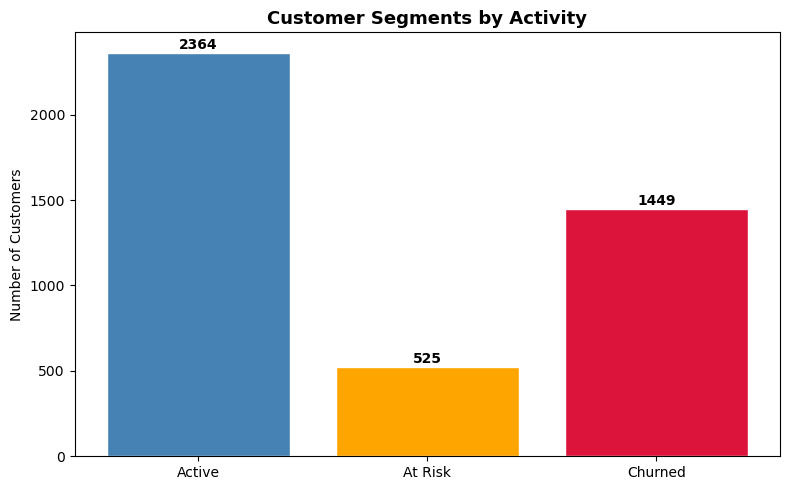

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

segment_counts = last_purchase['Segment'].value_counts().reindex(['Active', 'At Risk', 'Churned'])
colors = ['steelblue', 'orange', 'crimson']

bars = ax.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            str(val), ha='center', fontweight='bold')

ax.set_title('Customer Segments by Activity', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/churn_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

- **67% of customers are considered active**, having made at least one purchase within the last 90 days. The remaining 33% are classified as **churned** due to 90+ days of inactivity.

- The majority of active customers purchased within the last 30 days, indicating a healthy recent buyer base. **Loyalty actions** (e.g. personalized emails) could reinforce repeat purchases in this segment.

- **525 customers fall in the 60–90 day at-risk zone**, still active but approaching the churn threshold. Targeted re-engagement campaigns (email, SMS) are recommended to prevent churn.